<a href="https://colab.research.google.com/github/zmgriffin/Data201-labs/blob/main/Lab02_week2_Intro_to_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part 1 - Python Warm-Up

In [1]:
#variables and their values
age = 20
study_hours = 6
midterm_grade = 82
student_name = "Sara"
passed_midterm = True

print(age)
print(study_hours)
print(midterm_grade)

20
6
82


In [ ]:
#Find the data type
print(type(age))
print(type(student_name))
print(type(passed_midterm))

<class 'int'>
<class 'str'>
<class 'bool'>


### Part 2 — NumPy Arrays

In [2]:
import numpy as np
#NumPy is a Python library for working efficiently with numerical data.

ages = np.array([18, 21, 25, 32, 40])
print(ages)
print(type(ages))


age=(1,2,3)
print(age)
print(type(age))

[18 21 25 32 40]
<class 'numpy.ndarray'>
(1, 2, 3)
<class 'tuple'>


**Data Types**

* **Tuple:** Heterogeneous. It can store a mix of different data types (strings, numbers, booleans) together.
* **Array:** Homogeneous. Every element must be of the exact same data type.

**Mutability**

* **Tuple:** Immutable. Elements cannot be altered, added, or removed after creation.
* **Array:** Mutable. Individual elements can be modified, though total size is often fixed.

**Common Analogy**

* **Tuple:** Works like a database record or a lightweight struct with fixed positions.
* **Array:** Works like a mathematical vector or a simple inventory list.


In [ ]:
age.mean()

AttributeError: 'tuple' object has no attribute 'mean'

In [ ]:
ages.mean()

np.float64(27.2)

In [ ]:
ages.min()

np.int64(18)

In [ ]:
ages.max()

np.int64(40)

In [ ]:
income = np.array([30000, 45000, 52000, 75000, 120000])
income.mean()

np.float64(64400.0)

### Part 3 — Selecting Values

In [ ]:
ages

array([18, 21, 25, 32, 40])

In [ ]:
#selecting the first value: indexing
ages[0]

np.int64(18)

In [ ]:
#selecting second value to the fourth value
ages[1:4] # gives to n-1 value

array([21, 25, 32])

In [ ]:
ages[4]

np.int64(40)

In [ ]:
ages[[1,3]]

array([21, 32])

In [ ]:
#select the first and the fourth value from 'income'
income
income[[0,3]]

array([30000, 75000])

### Part 4 - Working With a Real Dataset

Upload the Auto dataset to the "Datasets" folder inside your Data_201 folder in Google Drive.

In Google Colab, connect your Google Drive by running:

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Define the file path

In [4]:
import pandas as pd
Auto = pd.read_csv("/content/drive/MyDrive/Data_201/Datasets/Auto.csv")

In [5]:
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


- What does each row represent? *A single car*


- What do columns represent? *Variables, or attributes of cars*
- Which variables look quantitative? *mgp, displacement, hp, weight, acceleration. year*
- Which might actually represent categories? *origin, name, cylinders is also categorical*

In [ ]:
Auto.shape

(397, 9)

In [ ]:
Auto["origin"].mean() #does this make sense?

np.float64(1.5743073047858942)

Origin mean is nonsense! Definitely really a categorical variable. Numbers stand for country/region

In [ ]:
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

### Part 5 — Data Quality and Missing Values

In [6]:
Auto.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
year,0
origin,0
name,0


### Part 6 — Selecting Features and Summarizing Data

In [ ]:
Auto["horsepower"]

,horsepower
0,130
1,165
2,150
3,150
4,140
...,...
392,86
393,52
394,84
395,79


In [ ]:
Auto[["horsepower", "mpg"]]

,horsepower,mpg
0,130,18.0
1,165,15.0
2,150,18.0
3,150,16.0
4,140,17.0
...,...,...
392,86,27.0
393,52,44.0
394,84,32.0
395,79,28.0


In [10]:
cars_small = Auto[["mpg", "horsepower", "weight"]]
cars_small.head()

,mpg,horsepower,weight
0,18.0,130,3504
1,15.0,165,3693
2,18.0,150,3436
3,16.0,150,3433
4,17.0,140,3449


Find the:

- average MPG
- minimum weight

In [ ]:
cars_small['mpg'].mean()

np.float64(23.51586901763224)

In [ ]:
cars_small['weight'].min()

1613

In [ ]:
#Now try to find the max of horsepower. What does the result mean?
cars_small['horsepower'].max()


'?'

The missing horsepower values are stored as the literal character "?"
Thus, pandas does not automatically recognize them as NaN.

That is why 'Auto.isna().sum()' showed 0!

In [11]:
cars_small["horsepower"] = cars_small["horsepower"].replace("?", pd.NA)

/tmp/ipykernel_2843/3934517978.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cars_small["horsepower"] = cars_small["horsepower"].replace("?", pd.NA)


In [12]:
#Then convert the column to numeric
cars_small["horsepower"] = pd.to_numeric(cars_small["horsepower"])

/tmp/ipykernel_2843/1029799381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cars_small["horsepower"] = pd.to_numeric(cars_small["horsepower"])


In [ ]:
cars_small["horsepower"].max()

230.0

### Part 7 — One-Hot Encoding


Machine-learning algorithms generally need numeric input. But some numbers in a dataset may actually represent categories rather than quantities.

**For Example**: The origin variable in Auto uses numbers to represent where the vehicle came from.

1 = USA
2 = Europe
3 = Japan

In [13]:
Auto["origin"].value_counts()

,count
origin,
1,248
3,79
2,70


In [ ]:
#Change the code to meaningful labels
Auto["origin_label"] = Auto["origin"].map({
    1: "USA",
    2: "Europe",
    3: "Japan"
})

In [ ]:
Auto[["origin", "origin_label"]].head()

,origin,origin_label
0,1,USA
1,1,USA
2,1,USA
3,1,USA
4,1,USA


In [ ]:
# Now one-hot encode
pd.get_dummies(Auto["origin_label"], dtype=int)

,Europe,Japan,USA
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
392,0,0,1
393,1,0,0
394,0,0,1
395,0,0,1


Instead of pretending that USA, Europe, and Japan have a numerical order, Python creates a separate 0/1 variable for each category. Because those numbers are just labels. They do not represent magnitude or order.

### Part 8 — Scaling

In [14]:
# fixing "horsepower" in Auto --> exact same thing done earlier in cars_small to replace the "?"
Auto["horsepower"] = Auto["horsepower"].replace("?", pd.NA)
Auto["horsepower"] = pd.to_numeric(Auto["horsepower"])

#check out the ranges. Which feature contains much larger numbers? --> WEIGHT is way larger. also note the five missing values in hp
Auto[["horsepower", "weight"]].describe()

,horsepower,weight
count,392.000000,397.000000
mean,104.469388,2970.261965
std,38.491160,847.904119
min,46.000000,1613.000000
25%,75.000000,2223.000000
50%,93.500000,2800.000000
75%,126.000000,3609.000000
max,230.000000,5140.000000


For algorithms based on distance, such as KNN, a variable with much larger numbers can dominate the distance calculation.

To avoid data leakage, I would not scale the entire dataset and then split it.

Here is the correct workflow right away.

In [15]:
from sklearn.model_selection import train_test_split

#We first separate the training data from the test data.
train_data, test_data = train_test_split(
    Auto,
    test_size=0.20,      #allocates 20% of the data to test_data
    random_state=42
)

In [17]:
# Import StandardScaler to scale numerical features (mean = 0, variance = 1)
from sklearn.preprocessing import StandardScaler

# Choose the numerical features you want to scale
features = ["horsepower", "weight"]

# Instantiate the scaler object
scaler = StandardScaler()

# Fit scaler on training data (calculates mean & std) AND transform it
#(make every row z-scores)
train_scaled = scaler.fit_transform(train_data[features])

# Transform test data using the parameters learned ONLY from training data
# note that the function is different!
test_scaled = scaler.transform(test_data[features])

Make the Scaling Visible

In [18]:
train_scaled = pd.DataFrame(
    train_scaled,
    columns=["horsepower_scaled", "weight_scaled"]
)

train_scaled.head()

,horsepower_scaled,weight_scaled
0,1.056681,0.528472
1,0.061392,-0.605951
2,-0.383868,0.273733
3,1.842435,1.671228
4,-1.012472,-1.405880


In [19]:
train_scaled.describe()

,horsepower_scaled,weight_scaled
count,3.140000e+02,3.170000e+02
mean,-8.768640e-17,-1.120730e-17
std,1.001596e+00,1.001581e+00
min,-1.536308e+00,-1.628480e+00
25%,-7.505537e-01,-9.023535e-01
50%,-2.921971e-01,-1.500393e-01
75%,6.572558e-01,7.748787e-01
max,3.282984e+00,2.569958e+00


- Are horsepower and weight still measured in their original units? *No! They are now z-scores! *

- Are their numerical scales now much more comparable? *Yes!*

### Part 9 — Quick Visualization

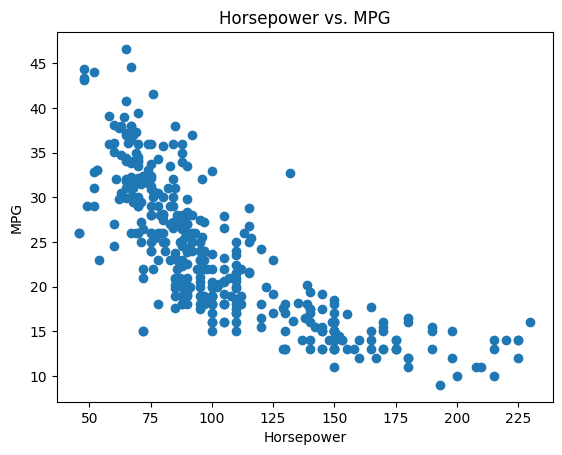

In [20]:
import matplotlib.pyplot as plt

plt.scatter(Auto["horsepower"], Auto["mpg"])

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs. MPG")

plt.show()

Describe the relationship in one sentence.
*As horespower increases, miles per gallon decreases.*